# 🤔 Config

In [ ]:
#|default_exp utils.config

In [ ]:
# |hide
import nbdev; nbdev.nbdev_export()

In [ ]:
# |hide
from nbdev.showdoc import DocmentTbl
from fastcore.test import test_eq

In [ ]:
# |hide
# |export
from copy import copy
from types import SimpleNamespace
from typing import Optional, Union, Callable, TypeVar
from contextlib import contextmanager
from lovely_numpy import config as np_config

In [ ]:
# |exporti

class Config(SimpleNamespace):
    "Config"
    precision: int
    threshold_max: int
    threshold_min: int
    sci_mode: Optional[bool]
    show_mem_above: int
    indent: int
    color: bool
    verbose_grad: bool
    deeper_width: int
    plt_seed: int
    fig_close: bool
    fig_show: bool
    show_histogram: bool
    def __init__(self,
            precision     = 3,    # Digits after `.`
            threshold_max = 3,    # .abs() larger than 1e3 -> Sci mode
            threshold_min = -4,   # .abs() smaller that 1e-4 -> Sci mode
            sci_mode      = None, # Sci mode (2.3e4). None=auto
            show_mem_above= 1024, # Show memory footprint above this threshold
            indent        = 2,    # Indent for .deeper()
            color         = True, # ANSI colors in text
            deeper_width  = 9,    # For .deeper, width per level
            verbose_grad  = True, # Print the gradient statistics
            plt_seed      = 42,   # Sampling seed for `plot`
            fig_close     = True, # Close matplotlib Figure
            fig_show      = False,# Call `plt.show()` for `.plt`, `.chans` and `.rgb`
            show_histogram= True, # Show the histogram in lovely(): '▁▂▃▃▆█▆▃▁▁'

    ):
        super().__init__(**{k:v for k,v in locals().items() if k not in ["self", "__class__"]})

_defaults = Config()
_config = copy(_defaults)

### Defaults:

In [ ]:
# |echo: false
DocmentTbl(Config)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| precision | int | 3 | Digits after `.` |
| threshold_max | int | 3 | .abs() larger than 1e3 -> Sci mode |
| threshold_min | int | -4 | .abs() smaller that 1e-4 -> Sci mode |
| sci_mode | NoneType | None | Sci mode (2.3e4). None=auto |
| show_mem_above | int | 1024 | Show memory footprint above this threshold |
| indent | int | 2 | Indent for .deeper() |
| color | bool | True | ANSI colors in text |
| deeper_width | int | 9 | For .deeper, width per level |
| verbose_grad | bool | True | Print the gradient statistics |
| plt_seed | int | 42 | Sampling seed for `plot` |
| fig_close | bool | True | Close matplotlib Figure |
| fig_show | bool | False | Call `plt.show()` for `.plt`, `.chans` and `.rgb` |
| show_histogram | bool | True | Show the histogram in lovely(): '▁▂▃▃▆█▆▃▁▁' |

In [ ]:
# |exporti

# Allows passing None as an argument to reset the
class _Default():
    def __repr__(self):
        return "Ignore"
D = _Default()
Default = TypeVar("Default")

In [ ]:
# |export

def set_config( precision       :Optional[Union[Default,int]]  =D,
                threshold_min   :Optional[Union[Default,int]]  =D,
                threshold_max   :Optional[Union[Default,int]]  =D,
                sci_mode        :Optional[Union[Default,bool]] =D,
                show_mem_above  :Optional[Union[Default,bool]] =D,
                indent          :Optional[Union[Default,bool]] =D,
                color           :Optional[Union[Default,bool]] =D,
                deeper_width    :Optional[Union[Default,int]]  =D,
                verbose_grad    :Optional[Union[Default,bool]] =D,
                plt_seed        :Optional[Union[Default,int]]  =D,
                fig_close       :Optional[Union[Default,bool]] =D,
                fig_show        :Optional[Union[Default,bool]] =D,
                show_histogram  :Optional[Union[Default,bool]]  =D,
                ) -> None:

    "Set config variables"
    args = locals().copy()
    for k,v in args.items():
        if v != D:
            if v is None:
                setattr(_config, k, getattr(_defaults, k))
            else:
                setattr(_config, k, v)

In [ ]:
# |export
def get_config() -> Config:
    "Get a copy of config variables"
    return copy(_config)

In [ ]:
# |export
@contextmanager
def config( precision       :Optional[Union[Default,int]]   =D,
            threshold_min   :Optional[Union[Default,int]]   =D,
            threshold_max   :Optional[Union[Default,int]]   =D,
            sci_mode        :Optional[Union[Default,bool]]  =D,
            show_mem_above  :Optional[Union[Default,bool]]  =D,
            indent          :Optional[Union[Default,bool]]  =D,
            color           :Optional[Union[Default,bool]]  =D,
            deeper_width    :Optional[Union[Default,int]]   =D,
            verbose_grad    :Optional[Union[Default,bool]]  =D,
            plt_seed        :Optional[Union[Default,int]]   =D,
            fig_close       :Optional[Union[Default,bool]]  =D,
            fig_show        :Optional[Union[Default,bool]]  =D,
            show_histogram  :Optional[Union[Default,bool]]  =D,
            ):


    "Context manager for temporarily setting printting options."
    global _config
    new_opts = { k:v for k, v in locals().items() if v != D }
    old_opts = copy(get_config().__dict__)

    try:
        set_config(**new_opts)
        yield
    finally:
        set_config(**old_opts)

## Examples

In [ ]:
# |hide

# In the next cell I'm importing the functios from the exported .py as part of the examples code
# This overrides the functions defined above!
# Make sure the code is in sync

import nbdev; nbdev.nbdev_export()

In [ ]:
import torch
from lovely_tensors import set_config, get_config, config, monkey_patch

In [ ]:
monkey_patch()

### Verbose gradient


In [ ]:
torch.manual_seed(1)
grad = torch.randn((10, 10), requires_grad=True)

print(f"After .backward():\n{grad}\n")

grad.prod().backward()

print(f"After .backward():\n{grad}\n")

with config(verbose_grad=False):
    print(f"After .backward() verbose_grad=False:\n{grad}\n")


After .backward():
tensor[10, 10] n=100 x∈[-3.331 |▁▁▁▃█▆▅▃▂▁| 2.357] μ=-0.203 σ=0.978 grad=None

After .backward():
tensor[10, 10] n=100 x∈[-3.331 |▁▁▁▃█▆▅▃▂▁| 2.357] μ=-0.203 σ=0.978 grad={ x∈[-3.465e-30 |▁  ▁█▁   ▁| 4.748e-30] μ=3.893e-32 σ=6.414e-31 }

After .backward() verbose_grad=False:
tensor[10, 10] n=100 x∈[-3.331 |▁▁▁▃█▆▅▃▂▁| 2.357] μ=-0.203 σ=0.978 grad*



### Histogram

In [ ]:
numbers = torch.load("mysteryman.pt")

print(numbers)
set_config(show_histogram=False)
print(numbers)

tensor[3, 196, 196] n=115248 (0.4Mb) x∈[-2.118 |▁▁▅█▁▁▁▁▂▁| 2.640] μ=-0.388 σ=1.073
tensor[3, 196, 196] n=115248 (0.4Mb) x∈[-2.118, 2.640] μ=-0.388 σ=1.073


### Precision

In [ ]:
set_config(precision=5)
torch.tensor([1., 2, float("nan")])

tensor[3] μ=1.50000 σ=0.70711 NaN! [1.00000, 2.00000, nan]

In [ ]:
# |hide
test_eq(str(torch.tensor([1., 2, float("nan")])),
        'tensor[3] μ=1.50000 σ=0.70711 \x1b[31mNaN!\x1b[0m [1.00000, 2.00000, nan]')

### Scientific mode

In [ ]:
set_config(sci_mode=True) # Force always on
torch.tensor([1., 2, float("nan")])

tensor[3] μ=1.50000e+00 σ=7.07107e-01 NaN! [1.00000e+00, 2.00000e+00, nan]

In [ ]:
#| hide
test_eq(str(torch.tensor([1., 2, float("nan")])),
        'tensor[3] μ=1.50000e+00 σ=7.07107e-01 \x1b[31mNaN!\x1b[0m [1.00000e+00, 2.00000e+00, nan]')

### Color on/off

In [ ]:
set_config(color=False) # Force always off
torch.tensor([1., 2, float("nan")])

tensor[3] μ=1.50000e+00 σ=7.07107e-01 NaN! [1.00000e+00, 2.00000e+00, nan]

In [ ]:
test_eq(str(torch.tensor([1., 2, float("nan")])),
        'tensor[3] μ=1.50000e+00 σ=7.07107e-01 NaN! [1.00000e+00, 2.00000e+00, nan]')

### Control .deeper

In [ ]:
set_config(deeper_width=3)
image = torch.load("mysteryman.pt")
image[1,100,100] = float('nan')

image.deeper(2)

tensor[3, 196, 196] n=115248 (0.4Mb) x∈[-2.11790e+00, 2.64000e+00] μ=-3.88310e-01 σ=1.07319e+00 NaN!
  tensor[196, 196] n=38416 x∈[-2.11790e+00, 2.24891e+00] μ=-3.24352e-01 σ=1.03588e+00
    tensor[196] x∈[-1.91241e+00, 2.24891e+00] μ=-6.73483e-01 σ=5.21962e-01
    tensor[196] x∈[-1.86103e+00, 2.16328e+00] μ=-7.38488e-01 σ=4.18080e-01
    tensor[196] x∈[-1.75828e+00, 2.19753e+00] μ=-8.05501e-01 σ=3.96848e-01
    ...
  tensor[196, 196] n=38416 x∈[-1.96569e+00, 2.42857e+00] μ=-2.73903e-01 σ=9.72665e-01 NaN!
    tensor[196] x∈[-1.86064e+00, 2.41106e+00] μ=-5.28772e-01 σ=5.55960e-01
    tensor[196] x∈[-1.82563e+00, 2.35854e+00] μ=-5.61732e-01 σ=4.72772e-01
    tensor[196] x∈[-1.75560e+00, 2.37605e+00] μ=-6.21756e-01 σ=4.58436e-01
    ...
  tensor[196, 196] n=38416 x∈[-1.80444e+00, 2.64000e+00] μ=-5.66673e-01 σ=1.17776e+00
    tensor[196] x∈[-1.71730e+00, 2.39599e+00] μ=-9.81537e-01 σ=3.50000e-01
    tensor[196] x∈[-1.75216e+00, 2.32627e+00] μ=-1.03418e+00 σ=3.13970e-01
    tensor[196] x∈[-

In [ ]:
test_eq(len(str(image.deeper(2))), 1062)

### In-memory size of data

In [ ]:
print(torch.ones((1024, 1024)))
set_config(show_mem_above=torch.inf) # Don't show the memory footprint
print(torch.ones((1024, 1024)))

tensor[1024, 1024] n=1048576 (4Mb) x∈[1.00000e+00, 1.00000e+00] μ=1.00000e+00 σ=0.
tensor[1024, 1024] n=1048576 x∈[1.00000e+00, 1.00000e+00] μ=1.00000e+00 σ=0.


### Reser to defaults

In [ ]:
set_config(precision=None, sci_mode=None, color=None, deeper_width=None, show_mem_above=None)
torch.tensor([1., 2, float("nan")])

tensor[3] μ=1.500 σ=0.707 NaN! [1.000, 2.000, nan]

In [ ]:
test_eq(str(torch.tensor([1., 2, float("nan")])),
    'tensor[3] μ=1.500 σ=0.707 \x1b[31mNaN!\x1b[0m [1.000, 2.000, nan]')

### Context manager

In [ ]:
display(torch.tensor([1., 2, torch.nan]))
with config(sci_mode=True, color=False):
    display(torch.tensor([1., 2, torch.nan]))
display(torch.tensor([1., 2, torch.nan]))

tensor[3] μ=1.500 σ=0.707 NaN! [1.000, 2.000, nan]

tensor[3] μ=1.500e+00 σ=7.071e-01 NaN! [1.000e+00, 2.000e+00, nan]

tensor[3] μ=1.500 σ=0.707 NaN! [1.000, 2.000, nan]

### Matplotlib and seed

In [ ]:
# |hide
import matplotlib

In [ ]:
# |hide

torch.manual_seed(42)
a = torch.randn(1000)
matplotlib.rcParams["svg.hashsalt"] = "1"
%config InlineBackend.print_figure_kwargs = {'metadata': {"Date": None, "Creator": "Matplotlib, https://matplotlib.org/" }}


In [ ]:
_ = a.plt() # The figure was closed, nothing is displayed

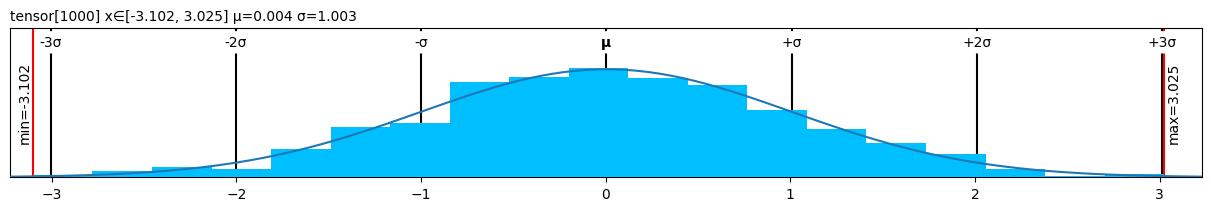

In [ ]:
set_config(fig_close=False)
_ = a.plt() # figure was not closed. All figures that are not closed are displayed after the cell runs.

In [ ]:
# |hide
set_config(fig_close=None)

For performance reasons, <code>.plt</code> will randomly sample up tp `max_s` elements from the data (10k be default).

You can change the seed used for this sampling (42 by default):

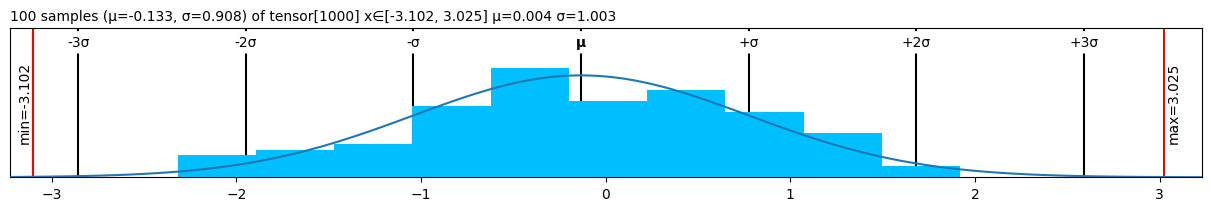

In [ ]:
set_config(plt_seed=1)
a.plt(max_s=100)

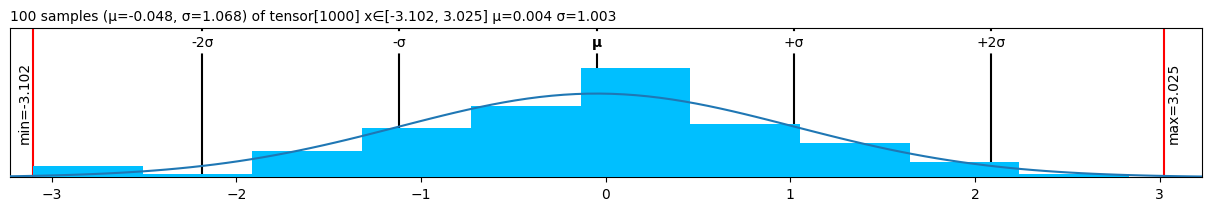

In [ ]:
set_config(plt_seed=2)
a.plt(max_s=100)

More details in [matplotlib](matplotlib.html)